# Explaining Neural Network Decisions on Data that have High-level Attributes

CEM_MAFImageExplainer from [AIX360](https://github.com/IBM/AIX360) can be used to obtain contrastive explanations on data that have pre-defined high-level attributes, such as facial images that are annotated with features such as smile, high cheekbones, makeup, etc.

The goal of this tutorial is to demonstrate the use of CEM_MAFImageExplainer, which offers two-part explanations based on a pertinent positive and a pertinent negative. The pertinent positive explanation outputs the minimal set of high-level features that must be present in order for the classification of a sample to remain the same, so that if any one of the output features was missing from the sample, the classification would be different.  The pertinent negative explanation outputs a set of features that would cause a change to the classification if they were added to the sample.

#### Import statements

In [1]:
import tensorflow as tf
import sys
import os
import numpy as np
import random
import matplotlib.pyplot as plt
from zipfile import ZipFile

from aix360.algorithms.contrastive import CEM_MAFImageExplainer
from aix360.algorithms.contrastive import CELEBAModel
from aix360.algorithms.contrastive import KerasClassifier
from aix360.algorithms.contrastive.dwnld_CEM_MAF_celebA import dwnld_CEM_MAF_celebA
from aix360.datasets.celeba_dataset import CelebADataset

dwnld = dwnld_CEM_MAF_celebA()

Using TensorFlow backend.


#### Assets used by this notebook

All model and data files below are fetched automatically over HTTPS from two Hugging Face repositories and verified against a pinned SHA-256 manifest before use:

- **Models** — [ibm-research/AIX360-CEM-MAF-USECASE](https://huggingface.co/ibm-research/AIX360-CEM-MAF-USECASE): the 8-class CelebA classifier being explained, the 15 attribute classifiers, and the [Karras et al. 2018 progressive-growing GAN](https://github.com/tkarras/progressive_growing_of_gans) weights.
- **Sample data** — [ibm-research/AIX360-CEM-MAF-data](https://huggingface.co/datasets/ibm-research/AIX360-CEM-MAF-data): pre-generated demo images and latents for ids `[2, 3, 4, 9, 11, 13, 15, 16, 18, 20]`.

No manual downloads or `PYTHONPATH` edits are required. The `dwnld.dwnld_celebA_*` calls in the cells below handle everything, and skip files whose local copy already matches the pinned hash. 

Note that the GAN model from [Karras et al. 2018 progressive-growing GAN](https://github.com/tkarras/progressive_growing_of_gans) is maintained under a different license: Creative Commons Attribution-NonCommercial 4.0 International Public License.

#### A Tensorflow session is required to run this example

In [2]:
sess = tf.InteractiveSession()
random.seed(120)
np.random.seed(1210)
sess.run(tf.global_variables_initializer())


2026-07-16 15:46:56.977307: I tensorflow/core/platform/cpu_feature_guard.cc:142] Your CPU supports instructions that this TensorFlow binary was not compiled to use: AVX2 FMA
2026-07-16 15:46:56.992403: I tensorflow/core/platform/profile_utils/cpu_utils.cc:94] CPU Frequency: 2599975000 Hz
2026-07-16 15:46:57.000622: I tensorflow/compiler/xla/service/service.cc:168] XLA service 0x55c6b41dabd0 initialized for platform Host (this does not guarantee that XLA will be used). Devices:
2026-07-16 15:46:57.000653: I tensorflow/compiler/xla/service/service.cc:176]   StreamExecutor device (0): Host, Default Version
2026-07-16 15:46:57.002188: W tensorflow/stream_executor/platform/default/dso_loader.cc:55] Could not load dynamic library 'libcuda.so.1'; dlerror: libcuda.so.1: cannot open shared object file: No such file or directory; LD_LIBRARY_PATH: /dccstor/rluss1/cudnn/cuda/lib64:/opt/share/cuda-11.6/x86_64/lib64/:/u/rluss/cuda/lib64/:/usr/lib64:/opt/share/ETELSFSH_FP15/10.1/linux4.18-glibc2.28-x

#### Load CelebA model to be explained. Model must first be downloaded.

In [3]:
# Download pretrained celebA model + GAN artifacts (safetensors + JSON sidecar).
# Both call sites are integrity-checked against pinned SHA-256s in
# dwnld_CEM_MAF_celebA.py; the GAN files land in aix360/models/CEM_MAF/gan/.
local_path_models = '../../aix360/models/CEM_MAF'
celebA_model_file = dwnld.dwnld_celebA_model(local_path_models)
gan_files = dwnld.dwnld_celebA_gan(local_path_models + '/gan')

Skipping celebA (local copy matches pinned hash)
celebA model file downloaded:
['../../aix360/models/CEM_MAF/celebA']
Skipping gan_weights.safetensors (local copy matches pinned hash)
Skipping gan_static_kwargs.json (local copy matches pinned hash)
GAN files downloaded:
['../../aix360/models/CEM_MAF/gan/gan_weights.safetensors', '../../aix360/models/CEM_MAF/gan/gan_static_kwargs.json']


In [4]:
# Load the downloaded celebA model
model_file = '../../aix360/models/CEM_MAF/celebA'
loaded_model = CELEBAModel(restore=model_file, use_softmax=False, device='/cpu:0').model

Instructions for updating:
If using Keras pass *_constraint arguments to layers.
Load: ../../aix360/models/CEM_MAF/celebA


#### Wrap the CelebA model into a framework independent class structure


In [5]:
mymodel = KerasClassifier(loaded_model, device='/cpu:0')

#### Download a sample image. Note: img_id must be from the following list: [2, 3, 4, 9, 11, 13, 15, 16, 18, 20]. These images are stored publicly and are downloaded here using the function dwnld.dwnld_celebA_data.  The second argument is a list of the image ids to be downloaded.¶

In [6]:
img_id = 15
local_path_img =  '../../aix360/data/celeba_data'
img_files = dwnld.dwnld_celebA_data(local_path_img, [img_id])

Skipping 15_img.npy (local copy matches pinned hash)
Skipping 15_latent.npy (local copy matches pinned hash)
Skipping 15_img.png (local copy matches pinned hash)
Image files downloaded:
['../../aix360/data/celeba_data/15_img.npy', '../../aix360/data/celeba_data/15_latent.npy', '../../aix360/data/celeba_data/15_img.png']


 #### Load the image and its latent representations, both to be used to generate a pertinent negative for the sample image. Then process the image and plot.

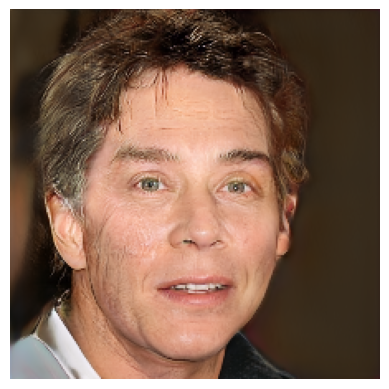

In [7]:
dataset_obj = CelebADataset(local_path_img) # use the CelebA dataset class
input_img = dataset_obj.get_img(img_id)
input_latent = dataset_obj.get_latent(img_id)

# images are processed according to needs for model being explained
input_img = np.clip(input_img/2, -0.5, 0.5)

plt.axis("off")
plt.imshow(input_img[0,:,:,:]+0.5)
plt.show()

#### Predict sample image using 8-class classifier based on 3 binary attributes: young (0 for old,  1 for young), smiling (0 for not smiling), 1 for smiling, and sex (0 for female, 1 for male).

In [8]:
orig_prob, orig_class, orig_prob_str = mymodel.predict_long(input_img)
# Compute classes
young_flag = orig_class % 2
smile_flag = (orig_class // 2) % 2
sex_flag = (orig_class // 4) % 2

arg_img_name = os.path.join(local_path_img, "{}_img.png".format(img_id))
print("Image:{}, pred:{}".format(arg_img_name, orig_class))
print("Male:{}, Smile:{}, Young:{}".format(sex_flag, smile_flag, young_flag))
orig_img = input_img
target_label = [np.eye(mymodel._nb_classes)[orig_class]]

Image:../../aix360/data/celeba_data/15_img.png, pred:4
Male:1, Smile:0, Young:0


#### Downloaded pretrained attribute classifiers to use for explaining the loaded model. Each attribute in the following list has a binary classifier to be taken as input to CEM_MAF.

In [9]:
attributes = ["Black_Hair", "Blond_Hair", "Brown_Hair", "Gray_Hair", "Wearing_Lipstick", "Heavy_Makeup",\
                "High_Cheekbones", "Bangs", "Oval_Face", "Narrow_Eyes", "Bags_Under_Eyes", "Pointy_Nose"]
# Download attribute functions
attr_model_files = dwnld.dwnld_celebA_attributes(local_path_models, attributes)

Attribute files downloaded:
['../../aix360/models/CEM_MAF/attr_model/simple_Black_Hair_model.json', '../../aix360/models/CEM_MAF/attr_model/simple_Black_Hair_weights.h5', '../../aix360/models/CEM_MAF/attr_model/simple_Blond_Hair_model.json', '../../aix360/models/CEM_MAF/attr_model/simple_Blond_Hair_weights.h5', '../../aix360/models/CEM_MAF/attr_model/simple_Brown_Hair_model.json', '../../aix360/models/CEM_MAF/attr_model/simple_Brown_Hair_weights.h5', '../../aix360/models/CEM_MAF/attr_model/simple_Gray_Hair_model.json', '../../aix360/models/CEM_MAF/attr_model/simple_Gray_Hair_weights.h5', '../../aix360/models/CEM_MAF/attr_model/simple_Wearing_Lipstick_model.json', '../../aix360/models/CEM_MAF/attr_model/simple_Wearing_Lipstick_weights.h5', '../../aix360/models/CEM_MAF/attr_model/simple_Heavy_Makeup_model.json', '../../aix360/models/CEM_MAF/attr_model/simple_Heavy_Makeup_weights.h5', '../../aix360/models/CEM_MAF/attr_model/simple_High_Cheekbones_model.json', '../../aix360/models/CEM_MAF/

#### Set up a CEM_MAF explainer object with respect to the trained CelebA model and high-level attributes.


In [10]:
aix360_path = '../../aix360' # needed to find paths to attribute files
explainer = CEM_MAFImageExplainer(mymodel, attributes, aix360_path)

#### Obtain the pertinent negative explaination

In [11]:
# parameter values for the pertinent negative
arg_mode = 'PN'
arg_kappa = 5
arg_gamma = 1
arg_binary_search_steps = 1
arg_max_iterations = 250
arg_initial_const = 10
arg_attr_reg = 100.0
arg_attr_penalty_reg = 100.0
arg_latent_square_loss_reg = 1.0

In [12]:
# gan_device pins the Karras GAN to a TF device. Use '/cpu:0' on Ampere/Hopper
# (A100, H100) to dodge a TF1.15 cuBLAS-10 SGEMM bug that NaN-corrupts the
# forward pass; on pre-Ampere GPUs (V100, T4, P100) leave gan_device=None.
# attr_classifier_device hits the same bug for the attribute classifiers —
# without '/cpu:0' on A100/H100, attr_score / attr_penalty in the loss are
# silently non-deterministic / NaN-corrupted.
(adv_pn, attr_pn, info_pn) = explainer.explain_instance(sess, input_img, 
                    input_latent, arg_mode, arg_kappa, arg_binary_search_steps, 
                    arg_max_iterations, arg_initial_const, arg_gamma, None, 
                    arg_attr_reg, arg_attr_penalty_reg, 
                    arg_latent_square_loss_reg, gan_device='/cpu:0',
                    attr_classifier_device='/cpu:0')
    
print(info_pn)


Instructions for updating:
Call initializer instance with the dtype argument instead of passing it to the constructor
Instructions for updating:
Call initializer instance with the dtype argument instead of passing it to the constructor
Instructions for updating:
Call initializer instance with the dtype argument instead of passing it to the constructor
Loaded model for Black_Hair from disk
Loaded model for Blond_Hair from disk
Loaded model for Brown_Hair from disk
Loaded model for Gray_Hair from disk
Loaded model for Wearing_Lipstick from disk
Loaded model for Heavy_Makeup from disk
Loaded model for High_Cheekbones from disk
Loaded model for Bangs from disk
Loaded model for Oval_Face from disk
Loaded model for Narrow_Eyes from disk
Loaded model for Bags_Under_Eyes from disk
Loaded model for Pointy_Nose from disk
# of attr models is 12









Instructions for updating:
Use tf.where in 2.0, which has the same broadcast rule as np.where

iter:0 const:[10.]
Loss_Overall:7786.6338, Loss_A

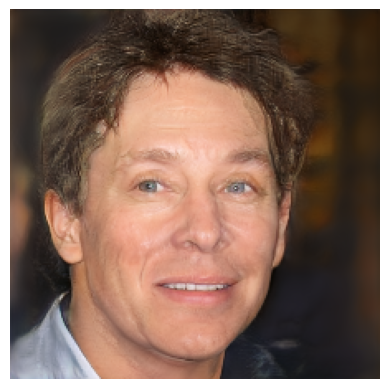

Pertinent Negative pred:6
Male:1, Smile:1, Young:0
Added High_Cheekbones


In [13]:
plt.axis("off")
plt.imshow(adv_pn[0,:,:,:]+0.5)
plt.show()
    
# Compute new classes
adv_prob, adv_class, adv_prob_str = mymodel.predict_long(adv_pn)
young_flag = adv_class % 2
smile_flag = (adv_class // 2) % 2
sex_flag = (adv_class // 4) % 2
print("Pertinent Negative pred:{}".format(adv_class))
print("Male:{}, Smile:{}, Young:{}".format(sex_flag, smile_flag, young_flag))
print(attr_pn)

#### Obtain the pertinent positive explaination

In [14]:
# Parameter values for the pertinent positive 
# Note that regularization parameters need for pertinent negative are not need here
arg_mode = 'PP'
arg_kappa = 5
arg_gamma = 100.0
arg_beta = 0.1
arg_binary_search_steps = 1
arg_max_iterations = 100
arg_initial_const = 10
    
# attr_classifier_device='/cpu:0' on A100/H100; same TF1.15 cuBLAS-10 SGEMM
# bug as gan_device, applied to the attribute classifiers feeding the PP loss.
(adv_pp, __, __) = explainer.explain_instance(sess, input_img, None, arg_mode, arg_kappa, 
                    arg_binary_search_steps, arg_max_iterations, 
                    arg_initial_const, arg_gamma, arg_beta,
                    attr_classifier_device='/cpu:0')

Creating a mask for pertinent positive
Loaded model for Black_Hair from disk
Loaded model for Blond_Hair from disk
Loaded model for Brown_Hair from disk
Loaded model for Gray_Hair from disk
Loaded model for Wearing_Lipstick from disk
Loaded model for Heavy_Makeup from disk
Loaded model for High_Cheekbones from disk
Loaded model for Bangs from disk
Loaded model for Oval_Face from disk
Loaded model for Narrow_Eyes from disk
Loaded model for Bags_Under_Eyes from disk
Loaded model for Pointy_Nose from disk
# of attr models is 12
iter:0 const:[10.]
Loss_Overall:4306.2983, Loss_Attack:0.0000, Loss_attr:0.3506
Loss_L2Dist:37763.0781, Loss_L1Dist:42590.1172, AE_loss:0.0
target_lab_score:2.6879, max_nontarget_lab_score:-4.9008

iter:10 const:[10.]
Loss_Overall:860.9397, Loss_Attack:0.0000, Loss_attr:0.4492
Loss_L2Dist:5139.8560, Loss_L1Dist:8160.2197, AE_loss:0.0
target_lab_score:4.3774, max_nontarget_lab_score:-11.3144

iter:20 const:[10.]
Loss_Overall:660.5618, Loss_Attack:0.0000, Loss_attr:0

#### Display the result and check the class

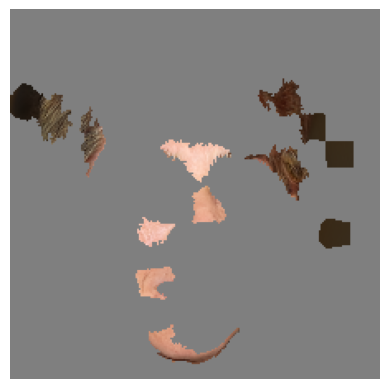

Pertinent positive pred:4
Male:1, Smile:0, Young:0


In [15]:
plt.axis("off")
plt.imshow(adv_pp[0,:,:,:]+0.5)
plt.show()
    
# Compute class of PP
adv_prob, adv_class, adv_prob_str = mymodel.predict_long(adv_pp)
young_flag = adv_class % 2
smile_flag = (adv_class // 2) % 2
sex_flag = (adv_class // 4) % 2
print("Pertinent positive pred:{}".format(adv_class))
print("Male:{}, Smile:{}, Young:{}".format(sex_flag, smile_flag, young_flag))